
Processing node 1
Running HiGHS 1.12.0 (git hash: 755a8e027): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 21 rows; 49 cols; 105 nonzeros; 49 integer variables (49 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+02, 1e+03]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
14 rows, 42 cols, 84 nonzeros  0s
14 rows, 42 cols, 84 nonzeros  0s
Presolve reductions: rows 14(-7); columns 42(-7); nonzeros 84(-21) 

Solving MIP model with:
   14 rows
   42 cols (42 binary, 0 integer, 0 implied int., 0 continuous, 0 domain fixed)
   84 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree

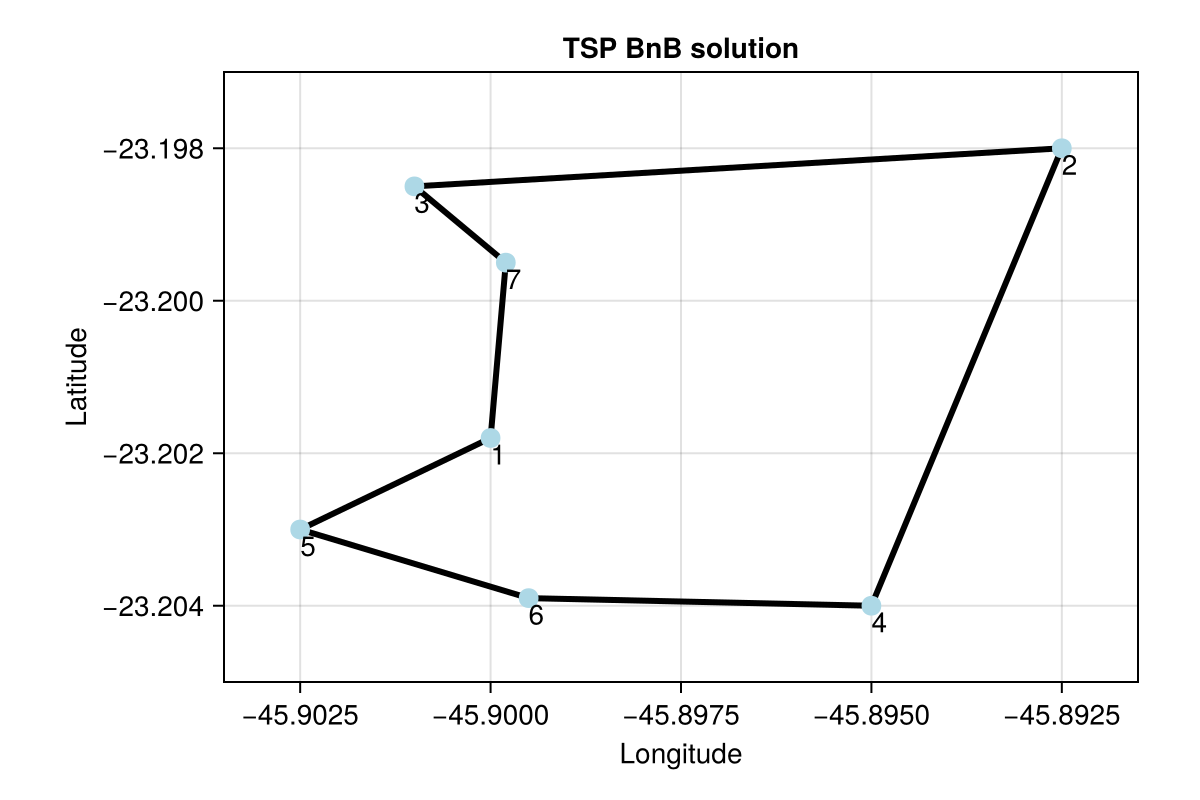

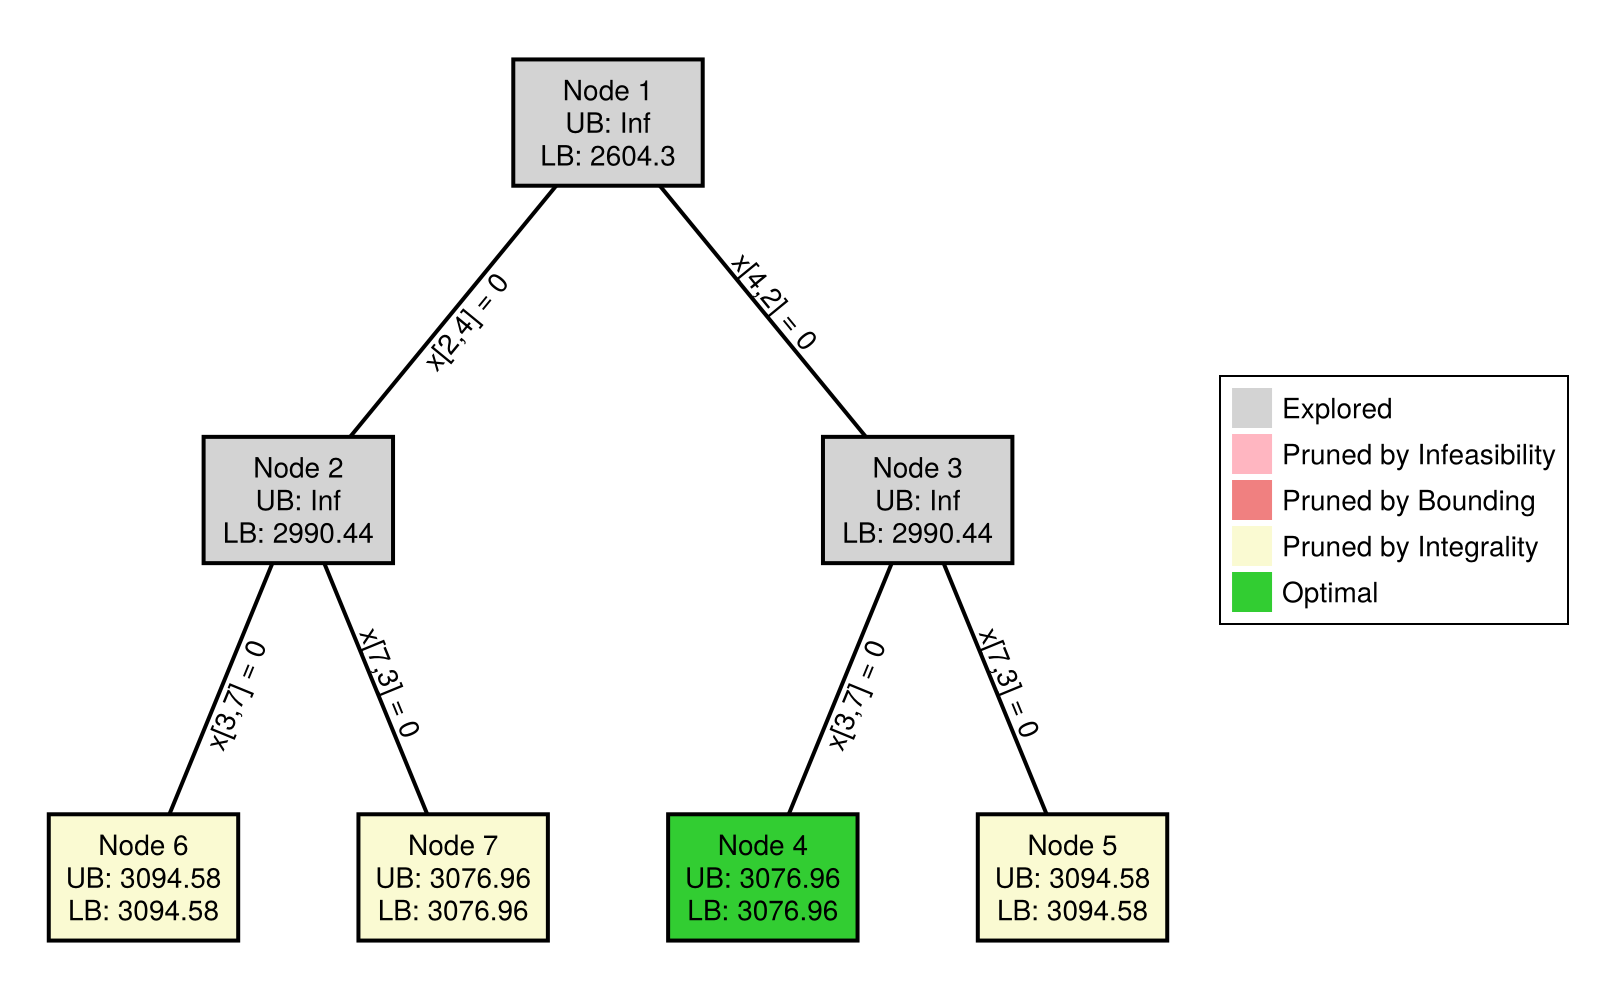

In [4]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 8 – Branch and Bound
#  Section: Exercise 3
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP, HiGHS, HDF5, Graphs, MetaGraphs, NetworkLayout, Colors, Makie, CairoMakie, GraphMakie

function plot_bb_tsp_solution(file_path::String, title::String, cycles)
    # Load data
    latitudes = h5read(file_path, "latitude")
    longitudes = h5read(file_path, "longitude")
    
    fig = Figure(size = (600, 400))
    ax = Axis(fig[1, 1];
        title = title,
        xlabel = "Longitude",
        ylabel = "Latitude",
        aspect = DataAspect(),
        limits = (
            (minimum(longitudes) - 0.001, maximum(longitudes) + 0.001),
            (minimum(latitudes) - 0.001, maximum(latitudes) + 0.001)
        )
    )

    # Plot all paths
    for (idx, cycle) in enumerate(cycles)
        closed_cycle = vcat(cycle, cycle[1])  # Close the tour
        cycle_longitudes = longitudes[closed_cycle]
        cycle_latitudes = latitudes[closed_cycle]
        lines!(ax, cycle_longitudes, cycle_latitudes;
            color = :black,
            linewidth = 3
        )
    end

    # Plot the points
    scatter!(ax, longitudes, latitudes;
        color = :lightblue,
        markersize = 14
    )

    # Annotate each point with its index
    for i in eachindex(longitudes)
        text!(ax, string(i), position = (longitudes[i], latitudes[i]), align = (:left, :top))
    end

    return fig
end

function plot_bb_tree(graph::MetaDiGraph)
    status_colors = Dict(
        :explored => colorant"lightgray",
        :pruned_by_infeasibility => colorant"lightpink",
        :pruned_by_bounding => colorant"lightcoral",
        :pruned_by_integrality => colorant"lightgoldenrodyellow",
        :optimal => colorant"limegreen"
    )

    node_labels = String[]
    for v in vertices(graph)
        ub = round(get_prop(graph, v, :ub), digits=2)
        lb = round(get_prop(graph, v, :lb), digits=2)
        base_label = "Node $(v)\nUB: $(ub)\nLB: $(lb)"
        push!(node_labels, base_label)
    end

    edge_labels = [get_prop(graph, e, :label) for e in edges(graph)]
    node_colors = [get(status_colors, get_prop(graph, v, :state), colorant"gray") for v in vertices(graph)]

    # Use a scalar for node_size, not a tuple
    node_size = (150,100)

    f, ax, p = GraphMakie.graphplot(graph,
        layout=NetworkLayout.Buchheim(),
        nlabels=node_labels,
        nlabels_fontsize=14,
        elabels_fontsize=14,
        node_color=node_colors,
        arrow_show=false,
        node_marker=:rect,
        node_size=node_size,
        node_strokewidth=2,
        node_strokecolor=:black,
        elabels=edge_labels, elabels_textsize=12,
        nlabels_align=(:center, :center), nlabels_textsize=10,
        edge_width=2, figure=(; size=(800, 500))
    )

    hidedecorations!(ax)
    hidespines!(ax)

    # Add margins to the plot
    ax.leftspinevisible = false
    ax.rightspinevisible = false
    ax.topspinevisible = false
    ax.bottomspinevisible = false
    ax.xautolimitmargin[] = (0.12, 0.12)
    ax.yautolimitmargin[] = (0.12, 0.12)

    # Create a legend
    elements = [
        PolyElement(color=status_colors[:explored]),
        PolyElement(color=status_colors[:pruned_by_infeasibility]),
        PolyElement(color=status_colors[:pruned_by_bounding]),
        PolyElement(color=status_colors[:pruned_by_integrality]),
        PolyElement(color=status_colors[:optimal])
    ]

    labels = [
        "Explored",
        "Pruned by Infeasibility",
        "Pruned by Bounding",
        "Pruned by Integrality",
        "Optimal"
    ]

    legend = Legend(f[1, 2], elements, labels; tellheight=false)
    f[1, 1] = ax
    f[1, 2] = legend

    return f
end

function solve_tsp_assignment(D, node_props)
    
    # Number of locations
    n = size(D, 1)

    # Create the model
    model = Model(HiGHS.Optimizer)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)

    # Objective function: minimize total distance
    @objective(model, Min, sum(D[i,j] * x[i,j] for i in 1:n, j in 1:n))

    # Eliminate diagonal assignments
    @constraint(model, [i=1:n], x[i,i] == 0)

    # Each column sums to 1 (each task assigned once)
    @constraint(model, [j=1:n], sum(x[i,j] for i in 1:n) == 1)

    # Each row sums to 1 (each agent assigned once)
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)

    # If there are fixed assignments, apply them
    for (coord, value) in node_props[:fixed]
        @constraint(model, x[coord[1],coord[2]] == value)
    end
    
    # Run the solver
    optimize!(model)

    # Check if the model was solved successfully
    if termination_status(model) != MOI.OPTIMAL
        return model, [], Inf
    end

    # Get the values of the decision variables
    x_opt = JuMP.value.(x)

    # Extract the tours
    visited = falses(n)
    cycles = []
    for start in 1:n
        if !visited[start]
            current = start
            cycle = Int[]
            while !visited[current]
                push!(cycle, current)
                visited[current] = true
                next_city = findfirst(x_opt[current, :] .== 1.0)
                current = next_city
            end
            push!(cycles, cycle)
        end
    end

    # Sort the cycles by size
    cycles = sort(cycles, by = length)

    # Print all cycles
    for (i, cycle) in enumerate(cycles)
        println("Tour $i: ", cycle)
    end

    # Get the optimal value of the objective function
    z_opt = JuMP.objective_value(model)
    println("Objective: $(round(z_opt,digits=2)) meters")

    return z_opt, cycles 
end

function solve_bnb_tsp(D)
    
    # Initialize the graph for the branch-and-bound tree
    graph = MetaDiGraph()

    # Add best_ub as a property to the graph
    set_prop!(graph, :best_id, 1)
    set_prop!(graph, :best_ub, Inf)
    set_prop!(graph, :best_ub_sol, [])

    # Add the root node to the graph
    add_vertex!(graph)
    root = Dict(
        :ub => Inf,
        :lb => -Inf,
        :fixed => Dict(),
        :cycles => [],
        :state => :explored)
    set_props!(graph, 1, root)
    
    # Initialize the active nodes list with the root node, and start the search
    active_nodes = [1]
    while !isempty(active_nodes)
        current_node = pop!(active_nodes)
        current_props = props(graph, current_node)

        println("\nProcessing node $current_node")

        # Solve the assignment problem for the current node
        z_opt, cycles = solve_tsp_assignment(D, current_props)

        # Update the properties of the current node
        current_props[:lb] = z_opt
        current_props[:cycles] = cycles

        # If the solution is infeasible, prune this node
        if z_opt == Inf
            println("Prunning node $current_node: infeasible solution found.")
            current_props[:state] = :pruned_by_infeasibility
            set_props!(graph, current_node, current_props)
            continue
        end

        # If we found a valid solution, update the properties
        if size(cycles, 1) == 1
            println("Found a valid solution at node $current_node with cost $z_opt.")
            current_props[:cycles] = cycles
            current_props[:state] = :pruned_by_integrality
            current_props[:ub] = z_opt
            # Check if we found a better solution
            if z_opt < get_prop(graph, :best_ub)
                set_prop!(graph, :best_id, current_node)
                set_prop!(graph, :best_ub, z_opt)
                set_prop!(graph, :best_ub_sol, cycles)
                println("Updated best solution with cost $z_opt.")
            end
            set_props!(graph, current_node, current_props)
            continue
        else
            println("Node $current_node has cycles: ", cycles)
            
            # Get the first cycle to branch on
            first_cycle = cycles[1]
            # Get the src and dest of the first cycle
            src = first_cycle[1]
            dst = first_cycle[2]

            # Create two new nodes for branching
            for branch in [:left, :right]
                add_vertex!(graph)
                new_node = nv(graph)
                new_props = Dict(
                    :ub => current_props[:ub],
                    :lb => current_props[:lb],
                    :fixed => copy(current_props[:fixed]),
                    :cycles => copy(current_props[:cycles]),
                    :state => :explored)

                # Update the fixed assignments based on the branch
                edge_props = Dict()
                if branch == :left
                    new_props[:fixed][(src, dst)] = 0
                    edge_props[:label] = "x[$src,$dst] = 0"
                else
                    new_props[:fixed][(dst, src)] = 0
                    edge_props[:label] = "x[$dst,$src] = 0"
                end

                set_props!(graph, new_node, new_props)
                push!(active_nodes, new_node)

                # Add edge from the current node to the new node
                add_edge!(graph, current_node, new_node, edge_props)
            end

        end
    end

    # After the search, update the :state of best node to :optimal
    best_id = get_prop(graph, :best_id)
    best_props = props(graph, best_id)
    best_props[:state] = :optimal
    set_props!(graph, best_id, best_props)

    return graph
end

# Load the distance matrix from the HDF5 file
D = h5read("data/tsp_bb_example.h5", "distance_matrix")

graph = solve_bnb_tsp(D)

# After the search, retrieve the best solution
println("\n==================\n")
best_id = get_prop(graph, :best_id)
best_ub = get_prop(graph, :best_ub)
best_ub_sol = get_prop(graph, :best_ub_sol)
println("Best solution found (Node $best_id) with cost $best_ub.")
println("Tour: ", best_ub_sol[1])

# Plot the solution using the utility function
p = plot_bb_tsp_solution("data/tsp_bb_example.h5", "TSP BnB solution", best_ub_sol)
display(p)

# Plot the branch-and-bound tree
plot_bb_tree(graph)